## 7. Python practice inside the financial workflow

The following cells deliberately use small financial examples before returning to the DataFrame. Read the output after each cell.

In [2]:
returns = [0.012, -0.006, 0.009, 0.004]

print('First return:', returns[0])
print('Last return:', returns[-1])
print('Middle returns:', returns[1:3])
print('Number of observations:', len(returns))

First return: 0.012
Last return: 0.004
Middle returns: [-0.006, 0.009]
Number of observations: 4


In [2]:
loan = {
    'balance': 12_000,
    'term_months': 36,
    'segment': 'Prime',
    'defaulted': False
}

print(loan['balance'])
print(loan['segment'])
print(list(loan.keys()))

12000
Prime
['balance', 'term_months', 'segment', 'defaulted']


In [2]:
pd_value = 0.08

if pd_value < 0.02:
    risk_band = 'low'
elif pd_value < 0.08:
    risk_band = 'medium'
else:
    risk_band = 'high'

print(risk_band)

for month, value in enumerate(returns, start=1):
    print(f'Month {month}: {value:.2%}')

high
Month 1: 1.20%
Month 2: -0.60%
Month 3: 0.90%
Month 4: 0.40%


In [2]:
def simple_interest(principal, rate, years):
    """Return simple interest; rate is a decimal."""
    return principal * rate * years

print(simple_interest(10_000, 0.06, 2))

def describe_return(value):
    return 'positive' if value > 0 else 'negative' if value < 0 else 'zero'

print([describe_return(value) for value in returns])

1200.0
['positive', 'negative', 'positive', 'positive']


# Machine Learning in Finance
## Lecture 0 and Lecture 1: course orientation and Python foundations

This notebook follows the presentation. It uses a public Apple price and volume dataset and is designed to run directly in Google Colab.

**Weekly submission:** extend this notebook according to `exercises/weekly_assignment.md` and submit it one day before the next course meeting.

## 1. Data source and imports

The CSV comes from the public Plotly datasets repository. The lecture uses the date, Apple closing price, and Apple trading volume columns.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
SOURCE_URL = (
    'https://raw.githubusercontent.com/plotly/'
    'datasets/master/finance-charts-apple.csv'
)

prices = pd.read_csv(SOURCE_URL, parse_dates=['Date'])
prices.head()

        Date   AAPL.Open   AAPL.High    AAPL.Low  AAPL.Close  AAPL.Volume  AAPL.Adjusted          dn        mavg          up   direction
0 2015-02-17  127.489998  128.880005  126.919998  127.830002     63152400     122.905254  106.741052  117.927667  129.114281  Increasing
1 2015-02-18  127.629997  128.779999  127.449997  128.720001     44891700     123.760965  107.842423  118.940333  130.038244  Increasing
2 2015-02-19  128.479996  129.029999  128.330002  128.449997     37362400     123.501363  108.894245  119.889167  130.884089  Decreasing
3 2015-02-20  128.619995  129.500000  128.050003  129.500000     48948400     124.510914  109.785449  120.763500  131.741551  Increasing
4 2015-02-23  130.020004  133.000000  129.660004  133.000000     70974100     127.876074  110.372516  121.720167  133.067817  Increasing

## 2. Define the analysis table

Short names make later calculations easier to read. The original source file remains unchanged in the repository.

In [2]:
prices = prices.rename(columns={
    'Date': 'date',
    'AAPL.Close': 'close',
    'AAPL.Volume': 'volume'
})
prices = prices.sort_values('date').reset_index(drop=True)

analysis = prices[['date', 'close', 'volume']].copy()
analysis.head(3)

        date       close    volume
0 2015-02-17  127.830002  63152400
1 2015-02-18  128.720001  44891700
2 2015-02-19  128.449997  37362400

## 3. First data audit

The audit establishes the data contract before interpretation: how many rows exist, what each column contains, which types were inferred, and whether values are missing.

In [2]:
print('Shape:', analysis.shape)
print('\nColumns:', analysis.columns.tolist())
print('\nDtypes:\n', analysis.dtypes)

missing = analysis.isna().sum()
audit = pd.DataFrame({
    'missing_count': missing,
    'missing_rate': (missing / len(analysis)).round(4)
})
audit

Shape: (506, 3)

Columns: ['date', 'close', 'volume']

Dtypes:
 date      datetime64[ns]
close            float64
volume             int64
dtype: object


        missing_count  missing_rate
date                0           0.0
close               0           0.0
volume              0           0.0

## 4. Descriptive statistics

The mean is the equal-weight centre of the observed values. The median is the middle ordered value. Standard deviation measures dispersion in the original unit. These are descriptive summaries, not forecasts.

In [2]:
summary = analysis['close'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
summary

count     506.000000
mean      112.958340
median    113.025002
std        11.244744
min        90.339996
max       135.509995

## 5. Returns

For price observations $P_t$, the simple return is $R_t = (P_t-P_{t-1})/P_{t-1}$. The first return is missing by construction because no lagged price exists.

In [2]:
analysis['simple_return'] = analysis['close'].pct_change()
analysis['log_return'] = np.log(analysis['close'] / analysis['close'].shift(1))

analysis[['date', 'close', 'simple_return', 'log_return']].head()

        date       close  simple_return  log_return
0 2015-02-17  127.830002            NaN         NaN
1 2015-02-18  128.720001       0.006962    0.006938
2 2015-02-19  128.449997      -0.002098   -0.002100
3 2015-02-20  129.500000       0.008174    0.008141
4 2015-02-23  133.000000       0.027027    0.026668

## 6. Visual evidence

Always label the variable, unit, and time period. A chart can reveal structure, but it cannot establish causality by itself.

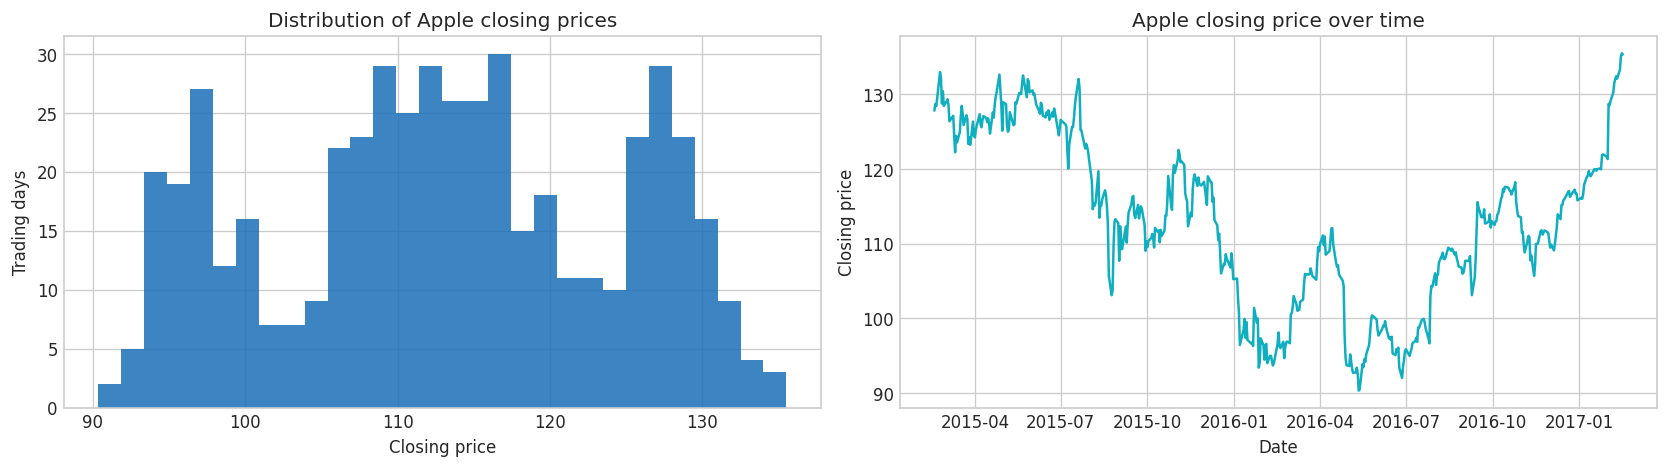

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(analysis['close'].dropna(), bins=30, color='#1B6FB8', alpha=0.85)
axes[0].set_title('Distribution of Apple closing prices')
axes[0].set_xlabel('Closing price')
axes[0].set_ylabel('Trading days')

axes[1].plot(analysis['date'], analysis['close'], color='#10AFC0', linewidth=1.5)
axes[1].set_title('Apple closing price over time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Closing price')

plt.tight_layout()
plt.show()

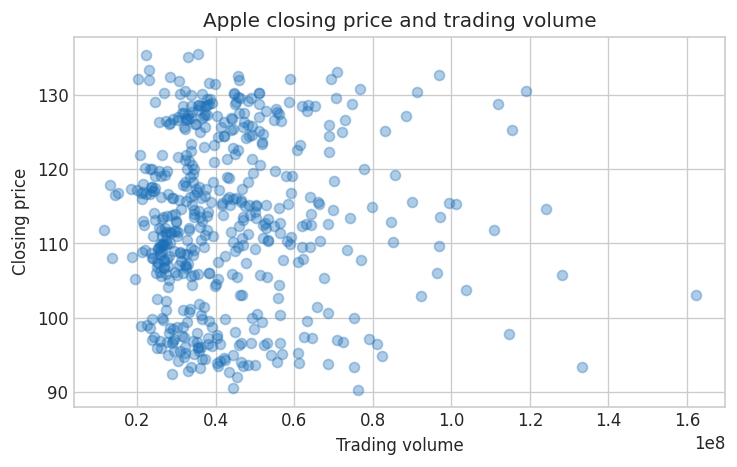

In [2]:
plt.figure(figsize=(7, 4))
plt.scatter(analysis['volume'], analysis['close'], alpha=0.35, color='#1B6FB8')
plt.title('Apple closing price and trading volume')
plt.xlabel('Trading volume')
plt.ylabel('Closing price')
plt.show()

## 8. Grouped financial summaries

The same grouped operation will later be used for borrower segments, calendar periods, and model-performance comparisons.

In [2]:
analysis['year'] = analysis['date'].dt.year
annual = (
    analysis.groupby('year')
    .agg(
        average_close=('close', 'mean'),
        median_close=('close', 'median'),
        average_volume=('volume', 'mean'),
        trading_days=('date', 'size')
    )
)
annual.head()

      average_close  median_close  average_volume  trading_days
year                                                           
2015     120.817027    122.669998    5.038081e+07           222
2016     104.604008    105.750000    3.841536e+07           252
2017     124.229062    121.489998    3.072094e+07            32

In [2]:
return_summary = analysis['simple_return'].describe()
correlation = analysis[['close', 'volume', 'simple_return']].corr()

print(return_summary)
print('\nCorrelation matrix:')
correlation

count    505.000000
mean       0.000230
std        0.015294
min       -0.065707
25%       -0.006607
50%        0.000000
75%        0.008281
max        0.064963
Name: simple_return, dtype: float64

Correlation matrix:


                  close    volume  simple_return
close          1.000000  0.023473       0.085744
volume         0.023473  1.000000      -0.156628
simple_return  0.085744 -0.156628       1.000000

## 9. A real credit-risk table

The course also uses a borrower-level credit-risk dataset. This cell downloads the official UCI archive directly, extracts the spreadsheet, and creates a DataFrame. The target records whether the borrower defaulted in the following month.

In [2]:
import io
import zipfile
from urllib.request import urlopen

credit_url = (
    'https://archive.ics.uci.edu/static/public/350/'
    'default+of+credit+card+clients.zip'
)
with urlopen(credit_url, timeout=60) as response:
    credit_bytes = response.read()

with zipfile.ZipFile(io.BytesIO(credit_bytes)) as archive:
    excel_name = archive.namelist()[0]
    with archive.open(excel_name) as stream:
        credit = pd.read_excel(stream, header=1)

print(credit.shape)
print(credit.columns.tolist())

(30000, 25)
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [2]:
target = 'default payment next month'

print(credit[target].value_counts())
print('Default rate:', round(credit[target].mean(), 4))

credit[['LIMIT_BAL', 'AGE', target]].describe()

default payment next month
0    23364
1     6636
Name: count, dtype: int64
Default rate: 0.2212


            LIMIT_BAL           AGE  default payment next month
count    30000.000000  30000.000000                30000.000000
mean    167484.322667     35.485500                    0.221200
std     129747.661567      9.217904                    0.415062
min      10000.000000     21.000000                    0.000000
25%      50000.000000     28.000000                    0.000000
50%     140000.000000     34.000000                    0.000000
75%     240000.000000     41.000000                    0.000000
max    1000000.000000     79.000000                    1.000000

In [2]:
credit.groupby(target).agg(
    average_limit=('LIMIT_BAL', 'mean'),
    median_age=('AGE', 'median'),
    observations=('ID', 'size')
)

                            average_limit  median_age  observations
default payment next month                                         
0                           178099.726074        34.0         23364
1                           130109.656420        34.0          6636

The credit table is now ready for later lectures on preprocessing, feature engineering, logistic regression, and model evaluation. The first responsibility is to define the target and inspect class balance before fitting a model.

## 7. Python cases across financial questions

The same Python structures can answer different questions. The next examples deliberately change the observation unit: first a short portfolio of positions, then daily market observations, and finally borrower records. The syntax stays familiar while the financial interpretation changes.

In [1]:
positions = {
    'equity_fund': {'weight': 0.50, 'return': 0.08},
    'bond_fund': {'weight': 0.30, 'return': 0.03},
    'cash': {'weight': 0.20, 'return': 0.01}
}

portfolio_return = sum(
    position['weight'] * position['return']
    for position in positions.values()
)

print(f'Portfolio return: {portfolio_return:.2%}')
print('Weights sum to:', sum(position['weight'] for position in positions.values()))

Portfolio return: 5.10%
Weights sum to: 1.0


The loop reads each position as a small record. The weighted return is an illustrative calculation, not an investment recommendation. The weight check is a data-quality control: a portfolio definition should sum to one before it is interpreted.

In [1]:
def return_summary(series):
    clean = series.dropna()
    return pd.Series({
        'observations': clean.size,
        'mean': clean.mean(),
        'median': clean.median(),
        'standard_deviation': clean.std(),
        'minimum': clean.min(),
        'maximum': clean.max()
    })

return_summary(analysis['simple_return']).round(5)

observations          505.00000
mean                    0.00023
median                  0.00000
standard_deviation      0.01529
minimum                -0.06571
maximum                 0.06496

A function makes the operation reusable. Instead of rewriting six descriptive-statistics calls for every variable, we pass a different pandas Series to the same function. This is the bridge from a one-off calculation to a reproducible analysis workflow.

In [1]:
annual_returns = (
    analysis.dropna(subset=['simple_return'])
    .groupby('year')['simple_return']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(5)
)

annual_returns.head()

      count     mean   median      std      min      max
year                                                    
2015    221 -0.00075 -0.00194  0.01631 -0.06116  0.05735
2016    252  0.00049  0.00081  0.01472 -0.06571  0.06496
2017     32  0.00494  0.00234  0.01144 -0.00418  0.06098

Grouping changes the question from “what is the whole-sample distribution?” to “how does the distribution differ by calendar year?” Always check the number of observations in each group before comparing averages.

## 9. Credit-risk cases before modelling

The credit table uses one row per borrower. The target is binary: zero means no default in the following month and one means default. The examples below show how to inspect class balance, compare groups, and create a transparent rule without claiming that the rule is a trained model.

In [1]:
class_balance = credit[target].value_counts().rename(index={0: 'No default', 1: 'Default'})
class_share = credit[target].value_counts(normalize=True).rename(index={0: 'No default', 1: 'Default'})

pd.DataFrame({
    'observations': class_balance,
    'share': class_share.round(4)
})

                            observations   share
default payment next month                      
No default                         23364  0.7788
Default                             6636  0.2212

Class balance matters because accuracy can look high when one class is much larger than the other. Before choosing a model or metric, state the target coding and report the share of each class.

In [1]:
credit['limit_band'] = pd.cut(
    credit['LIMIT_BAL'],
    bins=[-float('inf'), 100000, 300000, float('inf')],
    labels=['low limit', 'medium limit', 'high limit']
)

credit.groupby('limit_band', observed=False).agg(
    borrowers=('ID', 'size'),
    default_rate=(target, 'mean'),
    median_age=('AGE', 'median')
).round(4)

              borrowers  default_rate  median_age
limit_band                                       
low limit         12498        0.2948        32.0
medium limit      12939        0.1814        34.0
high limit         4563        0.1326        36.0

This grouped table is descriptive evidence. A difference in default rates across limit bands does not prove that the limit caused the difference. Later lectures will introduce validation, controls, and supervised models for prediction.

In [1]:
credit['simple_review_flag'] = (
    (credit['LIMIT_BAL'] < 50000)
    & (credit['PAY_0'] >= 2)
).astype(int)

credit.groupby('simple_review_flag')[target].agg(
    borrowers='size',
    default_rate='mean'
).round(4)

                    borrowers  default_rate
simple_review_flag                         
0                       29147        0.2072
1                         853        0.6999

The review flag is a transparent rule for learning purposes. It is not a credit policy and it has not been validated. The example shows why domain rules must be separated from model predictions and evaluated on data that the model did not use for development.

## 10. Weekly assignment extension